In [1]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd

c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [2]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
bwm_df = bwm_query()

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"
Downloading: C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\tmp6zrjb47y\cache.zip Bytes: 7275401


100%|██████████| 6.938363075256348/6.938363075256348 [00:00<00:00,  7.83it/s]


Loading bwm_query results from fixtures/2023_12_bwm_release.csv


### Decoding sessions based on regions

In [4]:
# eid from decoding example

decoding_eid = "b658bc7d-07cd-4203-8a25-7b16b549851b"

In [10]:
bwm_df.iloc[291:293]

,pid,eid,probe_name,session_number,date,subject,lab
291,b910cbe2-0c68-40b2-b9f1-268e7c28320a,b658bc7d-07cd-4203-8a25-7b16b549851b,probe01,1,2020-07-16,DY_014,danlab
292,ecde7e20-f135-47dd-8f96-adac49e4942e,b658bc7d-07cd-4203-8a25-7b16b549851b,probe00,1,2020-07-16,DY_014,danlab


In [9]:
MIN_RT = 0.08  # remove trials with reaction times above/below these values (seconds), if None, don't apply
MAX_RT = 2.0
MIN_LEN = None  # remove trials with length (feedback_time-goCue_time) above/below these value, if None, don't apply
MAX_LEN = None
EXCLUDE_UNBIASED = False

In [11]:
# download and see regions in data

# get only one probe

idx = bwm_df[bwm_df.eid == decoding_eid].index[1]  # take single probe
subject = bwm_df.iloc[idx]["subject"]
pid = bwm_df.iloc[idx]["pid"]
probe_name = bwm_df.iloc[idx]["probe_name"]

In [12]:
# load trials df
sess_loader = SessionLoader(one=one, eid=decoding_eid)
sess_loader.load_trials()



# create mask
trials_df, trials_mask = load_trials_and_mask(
    one=one,
    eid=decoding_eid,
    sess_loader=sess_loader,
    min_rt=MIN_RT,
    max_rt=MAX_RT,
    min_trial_len=MIN_LEN,
    max_trial_len=MAX_LEN,
    exclude_nochoice=True,
    exclude_unbiased=False,
)

In [13]:
spikes, clusters = load_good_units(one, pid, eid=decoding_eid, pname=probe_name)

C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\danlab\Subjects\DY_014\2020-07-16\001\alf\probe00\pykilosort\spikes.amps.npy: 100%|██████████| 44.8M/44.8M [00:02<00:00, 22.3MB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\danlab\Subjects\DY_014\2020-07-16\001\alf\probe00\pykilosort\spikes.clusters.npy: 100%|██████████| 22.4M/22.4M [00:00<00:00, 28.6MB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\danlab\Subjects\DY_014\2020-07-16\001\alf\probe00\pykilosort\spikes.depths.npy: 100%|██████████| 44.8M/44.8M [00:01<00:00, 33.8MB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\danlab\Subjects\DY_014\2020-07-16\001\alf\probe00\pykilosort\spikes.times.npy: 100%|██████████| 44.8M/44.8M [00:01<00:00, 43.4MB/s]
C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\danlab\Subjects\DY_014\2020-07-16\001\alf\probe00\pykilosort\clusters.channels.npy: 100%|██████████| 2.78k/2.78k [00:00<00:00, 9.01kB/s]
C:\Users\deb

In [15]:

def find_pids(one):
    """Return eids for animal sessions that have the regions we want

    Args:
        one (ONE): working connection to ONE

    Returns:
        list, list, list, list: Returns eids for sessions that have insertions
        in ACC and CA1, ACC and PFC, PFC and CA1, and a union of all three
        conditions.
    """

    hippocampal_regions = [
        "CA",
        "CA1",
        "CA1slm",
        "CA1so",
        "CA1sp",
        "CA1sr",
    ]
    pfc_regions = [
        "VISa",
        "VISa1",
        "VISa2/3",
        "VISa4",
        "VISa5",
        "VISa6a",
        "VISam",
        "VISam1",
        "VISam2/3",
        "VISam4",
        "VISam5",
        "VISam6a",
        "VISam6b",
    ]

    pfc_eids = []
    for acronym in tqdm(pfc_regions):
        sessions = one.search(
            atlas_acronym=acronym,
            query_type="remote",
            dataset="spikes.clusters.npy",
            project="brainwide",
        )
        for idx in sessions:
            pfc_eids.append(idx)

    pfc_eids = list(set(pfc_eids))

    hippocampal_eids = []
    for acronym in tqdm(hippocampal_regions):
        sessions = one.search(
            atlas_acronym=acronym,
            query_type="remote",
            dataset="spikes.clusters.npy",
            project="brainwide",
        )
        for idx in sessions:
            hippocampal_eids.append(idx)

    hippocampal_eids = list(set(hippocampal_eids))

    # now we have all the eids
    PFC_CA1 = list(set(hippocampal_eids).intersection(pfc_eids))

    return np.sort(PFC_CA1), np.sort(hippocampal_eids), np.sort(pfc_eids)

In [16]:
visam_ca1_eids, ca1_eids, visa_eids = find_pids(one)

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [24]:
# bwm_df query indices visa_eids[3], index[0] (LP, CA, VISA),
# also decoding example animal
# nice subject -> CSHL059, eid=dda5fc59-f09a-4256-9fb5-66c67667a466
# nice subject -> ibl_witten_27, eid=f304211a-81b1-446f-a435-25e589fe3a5a


In [56]:
bwm_df[bwm_df['subject']=='ibl_witten_27']

,pid,eid,probe_name,session_number,date,subject,lab
610,76c5c1a1-3617-4727-9f75-d975c9a08203,25d1920e-a2af-4b6c-9f2e-fc6c65576544,probe01,2,2021-01-13,ibl_witten_27,wittenlab
611,c0e59477-43f0-4441-9f81-3a55ddad9dad,25d1920e-a2af-4b6c-9f2e-fc6c65576544,probe00,2,2021-01-13,ibl_witten_27,wittenlab
612,37137b1d-34d4-4183-9796-abfc9ffb6abe,91e04f86-89df-4dec-a8f8-fa915c9a5f1a,probe00,1,2021-01-15,ibl_witten_27,wittenlab
613,30dfb8c6-9202-43fd-a92d-19fe68602b6f,c728f6fd-58e2-448d-aefb-a72c637b604c,probe00,3,2021-01-16,ibl_witten_27,wittenlab
614,4037a618-e6ba-4142-a6d2-3e32ef25fd1b,c728f6fd-58e2-448d-aefb-a72c637b604c,probe01,3,2021-01-16,ibl_witten_27,wittenlab
615,19137f8d-0f3b-4923-93ad-f741758e1b2e,952870e5-f2a7-4518-9e6d-71585460f6fe,probe01,1,2021-01-19,ibl_witten_27,wittenlab
616,727ff7c4-d63f-4bd8-9888-f134a25b874f,952870e5-f2a7-4518-9e6d-71585460f6fe,probe00,1,2021-01-19,ibl_witten_27,wittenlab
617,94761f31-0dfc-4f67-87ef-6d1ac7f95144,f304211a-81b1-446f-a435-25e589fe3a5a,probe01,1,2021-01-20,ibl_witten_27,wittenlab
618,f31bef35-3f56-4ca9-a34f-09d678f03039,f304211a-81b1-446f-a435-25e589fe3a5a,probe00,1,2021-01-20,ibl_witten_27,wittenlab
619,0851db85-2889-4070-ac18-a40e8ebd96ba,73918ae1-e4fd-4c18-b132-00cb555b1ad2,probe01,1,2021-01-21,ibl_witten_27,wittenlab


In [57]:
np.argwhere(visa_eids=='dda5fc59-f09a-4256-9fb5-66c67667a466')
np.argwhere(visa_eids=='f304211a-81b1-446f-a435-25e589fe3a5a')

array([[81]], dtype=int64)

In [58]:
# aggregate statistics for a given eid

eid = visa_eids[81]
idx = bwm_df[bwm_df.eid == eid].index[0]
subject = bwm_df.iloc[idx]["subject"]
pid = bwm_df.iloc[idx]["pid"]
probe_name = bwm_df.iloc[idx]["probe_name"]

In [59]:
# load trials df
sess_loader = SessionLoader(one=one, eid=eid)
sess_loader.load_trials()



# create mask
trials_df, trials_mask = load_trials_and_mask(
    one=one,
    eid=eid,
    sess_loader=sess_loader,
    min_rt=MIN_RT,
    max_rt=MAX_RT,
    min_trial_len=MIN_LEN,
    max_trial_len=MAX_LEN,
    exclude_nochoice=True,
    exclude_unbiased=False,
)

In [60]:
spikes, clusters = load_good_units(one, pid, eid=eid, pname=probe_name)

In [61]:
np.unique(clusters.acronym, return_counts=True)

(array(['APN', 'CA1', 'MB', 'MRN', 'VISam5'], dtype=object),
 array([17,  4,  1,  3,  4], dtype=int64))

In [62]:
# get align times, plot peths, maybe firing rates

# ----------------------------STIMONSET---------------------------------#
correct_trials = trials_df[trials_mask][trials_df[trials_mask]["feedbackType"] == 1]
visible_trials_left = correct_trials.contrastLeft.isin([1, 0.25, 0.125, 0.0625])
visible_trials_right = correct_trials.contrastRight.isin([1, 0.25, 0.125, 0.0625])
visible_trials = visible_trials_left | visible_trials_right
trials_in_consideration = correct_trials[visible_trials]


time_window_stim = [0.0, 0.1]
events_stim = trials_in_consideration.stimOn_times
events_stim_tw = np.array([events_stim + time_window_stim[0], events_stim + time_window_stim[1]]).T

## for left and right sided visible stimulus, only correct trials

spike_count_stim, cluster_id = get_spike_counts_in_bins(
    spikes["times"], spikes["clusters"], events_stim_tw
)

# also, now for single cells, to be used for a lag based analysis
p_eths, bin_counts_stim = singlecell.calculate_peths(
    spikes["times"],
    spikes["clusters"],
    cluster_id,
    align_times=events_stim,
    smoothing=False,
    bin_size=0.01,
    pre_time=0.0,
    post_time=0.1,
    return_fr=True
)

In [63]:
spike_count_stim.shape # neurons x trials 

(29, 427)

<BarContainer object of 29 artists>

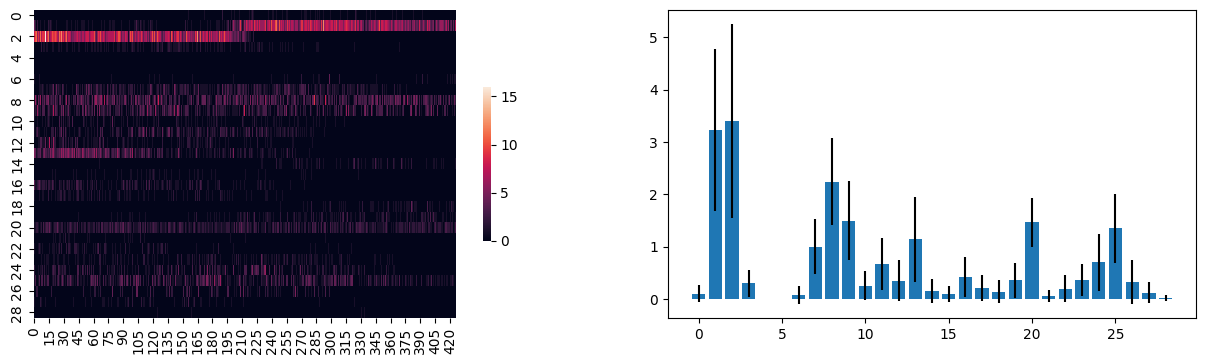

In [64]:
fig, ax = plt.subplots(figsize=(15,4), ncols=2) 
sns.heatmap(spike_count_stim,ax=ax[0],cbar_kws={'shrink':0.5})
ax[1].bar(np.arange(spike_count_stim.shape[0]), np.mean(spike_count_stim,axis=1), yerr=np.std(spike_count_stim,axis=1)/2)

### Single session decoding results

In [4]:
sessions_stimside = pd.read_parquet('../data/external/stimside_stage2.pqt')
sessions_choice = pd.read_parquet('../data/external/choice_stage2.pqt')
sessions_feedback = pd.read_parquet('../data/external/feedback_stage2.pqt')


In [17]:
significant_stimside = sessions_stimside[sessions_stimside['p-value']<0.05]
significant_choice = sessions_choice[sessions_choice['p-value']<0.05]
significant_feedback = sessions_feedback[sessions_feedback['p-value']<0.05]

In [45]:
# session with significant decoding everywhere

best_sessions = set(significant_choice.eid).intersection(set(significant_feedback.eid)).intersection(set(significant_stimside.eid))

In [46]:
best_sessions = np.asarray(list(best_sessions))

In [51]:
## find intersections 

stimside_considerations = significant_stimside[significant_stimside.eid.isin(best_sessions)]
choice_considerations = significant_choice[significant_choice.eid.isin(best_sessions)]
feedback_considerations = significant_feedback[significant_feedback.eid.isin(best_sessions)]

In [55]:
## now to find sessions with nice regions



In [61]:
stimside_aggregate = stimside_considerations.groupby('eid')['region'].unique().reset_index()
choice_aggregate = choice_considerations.groupby('eid')['region'].unique().reset_index()
feedback_aggregate = feedback_considerations.groupby('eid')['region'].unique().reset_index()

In [71]:
temp = pd.merge(stimside_aggregate, choice_aggregate, on='eid')
final_df = pd.merge(temp, feedback_aggregate, on='eid')

In [72]:
final_df

,eid,region_x,region_y,region
0,03063955-2523-47bd-ae57-f7489dd40f15,[ACB],"[ACB, COAp, CP, MOp]","[ACB, BMA, COAp, CP, MOp]"
1,032ffcdf-7692-40b3-b9ff-8def1fc18b2e,"[PBG, VISp]","[PBG, POST]","[CA1, CA2, CA3, NB, PBG, VISp]"
2,034e726f-b35f-41e0-8d6c-a22cc32391fb,[LGd],"[AV, CA1, CA3, LGd, VAL, VISrl]","[AV, CA1, CA3, LD, LGd, VAL, VISrl, ZI]"
3,037d75ca-c90a-43f2-aca6-e86611916779,"[IP, IRN, LAV, PARN, PGRN, SPIV, SUV]","[IP, IRN, LAV, NTS, PARN, PGRN, SPIV, SUV]","[IRN, LAV, NTS, PARN, PGRN, SPIV, SUV]"
4,03cf52f6-fba6-4743-a42e-dd1ac3072343,[MRN],"[MRN, POL, SCm]","[MRN, POL, SCm, VISp]"
...,...,...,...,...
274,fd03d365-91df-41e2-ad81-9e0e4b9f5c7b,[MRN],"[CS, MRN, PAG, POST, RSPv, SCm, SCs]","[CS, MRN, PAG, POST, RSPv, SCm, SCs]"
275,fe1fd79f-b051-411f-a0a9-2530a02cc78d,"[NOT, NPC]","[MEA, NOT, NPC, PAG]","[LHA, MEA, NOT, NPC, OP, PAG, PPT, SI, SUB]"
276,fece187f-b47f-4870-a1d6-619afe942a7d,"[IRN, PRNc, SSp-bfd, VII]","[IRN, PAG, PRNc, RT, SSp-bfd, VII]","[IRN, PAG, PRNc, RT, SSp-bfd, VII]"
277,ff4187b5-4176-4e39-8894-53a24b7cf36b,"[GPe, MOs]","[ACAd, BLA, CP, EPv, GPe, LSr, MOs]","[ACAd, BLA, CEA, CP, EPv, GPe, LSr, MOs, PAA, PL]"


In [75]:
final_df.columns = ['eid','stim','choice','feedback']

In [87]:
final_df['regions'] = final_df[['stim','choice','feedback']].apply(lambda row: np.concatenate(row).tolist(), axis=1)

C:\Users\debot\AppData\Local\Temp\ipykernel_19252\4240217831.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_df['regions'] = final_df[['stim','choice','feedback']].apply(lambda row: np.concatenate(row).tolist(), axis=1)


In [91]:
final_df.regions.apply(lambda x:len(x))

0      10
1      10
2      15
3      22
4       8
       ..
274    15
275    15
276    16
277    19
278    14
Name: regions, Length: 279, dtype: int64

In [93]:
# save the results

final_df.to_csv('../data/processed/good_sessions.csv',index=False)

### Download data 

In [127]:
def download_data(one, pid):
    spikes, clusters = load_good_units(one, pid, compute_metrics=False)
    return spikes, clusters

In [105]:
bwm_df[bwm_df['eid'].isin(final_df.eid)]

,pid,eid,probe_name,session_number,date,subject,lab
0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,probe00,1,2020-02-18,NYU-11,angelakilab
1,47be9ae4-290f-46ab-b047-952bc3a1a509,56956777-dca5-468c-87cb-78150432cc57,probe01,1,2020-02-21,NYU-11,angelakilab
2,6be21156-33b0-4f70-9a0f-65b3e3cd6d4a,56956777-dca5-468c-87cb-78150432cc57,probe00,1,2020-02-21,NYU-11,angelakilab
3,8dfb86c8-d45c-46c4-90ec-33078014d434,4364a246-f8d7-4ce7-ba23-a098104b96e4,probe01,1,2020-01-20,NYU-12,angelakilab
4,c893c0a3-5597-49cf-baa1-60efdfdef542,b182b754-3c3e-4942-8144-6ee790926b58,probe01,1,2020-01-21,NYU-12,angelakilab
...,...,...,...,...,...,...,...
694,8bf0f1a4-0d8c-4df3-a99e-f7c81c809652,993c7024-0abc-4028-ad30-d397ad55b084,probe01,1,2020-09-16,CSH_ZAD_029,zadorlab
695,5d570bf6-a4c6-4bf1-a14b-2c878c84ef0e,fece187f-b47f-4870-a1d6-619afe942a7d,probe01,1,2020-09-17,CSH_ZAD_029,zadorlab
696,f7c93877-ec05-4091-a003-e69fae0f2fa8,fece187f-b47f-4870-a1d6-619afe942a7d,probe00,1,2020-09-17,CSH_ZAD_029,zadorlab
697,675952a4-e8b3-4e82-a179-cc970d5a8b01,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,probe01,1,2020-09-19,CSH_ZAD_029,zadorlab


In [118]:
# regions we want

regions_of_interest = ['CP','ACAd','VISA','VISAm','MRN','CA1','CA3']

In [119]:
final_df['matches'] = final_df['regions'].apply(lambda x: len(set(x).intersection(regions_of_interest)))

In [120]:
filtered_df = final_df[final_df['matches'] > 0].sort_values(by='matches', ascending=False).reset_index(drop=True)

In [122]:
filtered_df[filtered_df.matches==3]

,eid,stim,choice,feedback,regions,matches
0,37e96d0b-5b4b-4c6e-9b29-7edbdc94bbd0,"[CA1, CP]","[AAA, APN, CA1, CP, FS, MRN]","[AAA, APN, COAa, CP, DG, FS, MRN, ProS]","[CA1, CP, AAA, APN, CA1, CP, FS, MRN, AAA, APN...",3
1,b52182e7-39f6-4914-9717-136db589706e,"[APN, VISam, VISpm]","[APN, DG, MRN, VISam, VISpm]","[APN, CA1, CA3, DG, MRN, VISam, VISpm]","[APN, VISam, VISpm, APN, DG, MRN, VISam, VISpm...",3
2,f312aaec-3b6f-44b3-86b4-3a0c119c0438,"[LP, VISa]","[CA1, LP, VISa]","[APN, CA1, CA3, LP, MRN, PO, VISa]","[LP, VISa, CA1, LP, VISa, APN, CA1, CA3, LP, M...",3
3,54238fd6-d2d0-4408-b1a9-d19d24fd29ce,"[MRN, PRNr, SCm, VPL, ZI]","[MRN, PPN, PRNr, SOC, VPL, VPM]","[CA1, CA3, DG, LGd, LP, MRN, PPN, PRNr, SCm, S...","[MRN, PRNr, SCm, VPL, ZI, MRN, PPN, PRNr, SOC,...",3
4,7af49c00-63dd-4fed-b2e0-1b3bd945b20b,"[POL, SGN, SSp-m]","[CA1, CP, DG, Eth, LP, MRN, POL, PoT, SGN, SPF...","[CP, DG, Eth, LP, MRN, POL, PoT, SGN, SPF, SSp...","[POL, SGN, SSp-m, CA1, CP, DG, Eth, LP, MRN, P...",3
5,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b,[VISa],"[APN, BMA, CP, MRN, PAA, POL, VISa, VISam]","[APN, BMA, CA1, CP, DG, FS, LP, MRN, PAA, POL,...","[VISa, APN, BMA, CP, MRN, PAA, POL, VISa, VISa...",3
6,4a45c8ba-db6f-4f11-9403-56e06a33dfa4,"[CA2, MRN, SCm, VPM]","[CA1, CA3, LGd, MRN, RN, RSPv, SCm, VISa, VPL,...","[CA1, CA2, CA3, MRN, RN, SCm, SCs, VISa, VPM, ZI]","[CA2, MRN, SCm, VPM, CA1, CA3, LGd, MRN, RN, R...",3
7,0cbeae00-e229-4b7d-bdcc-1b0569d7e0c3,[CP],"[CP, VPL]","[CA1, CA3, CP, LA, LGd, SSp-bfd, VPL, VPM, ZI]","[CP, CP, VPL, CA1, CA3, CP, LA, LGd, SSp-bfd, ...",3
8,eacc49a9-f3a1-49f1-b87f-0972f90ee837,"[MRN, PAG, SCm, SCs]","[CA1, CA2, MRN, PAG, RN, RSPagl, RSPd, RSPv, S...","[CA1, CA2, CA3, EPv, MRN, PAG, RN, RSPv, SCm, ...","[MRN, PAG, SCm, SCs, CA1, CA2, MRN, PAG, RN, R...",3


In [124]:
# choose the eids with most of the regions we want

eids_to_download = filtered_df[filtered_df.matches==3].eid

In [ ]:
# now to find the pids 
for eid in tqdm(eids_to_download):
    pids, probes = one.eid2pid(eid)
    for pid in pids:
        download_data(one, pid)

0it [00:00, ?it/s]

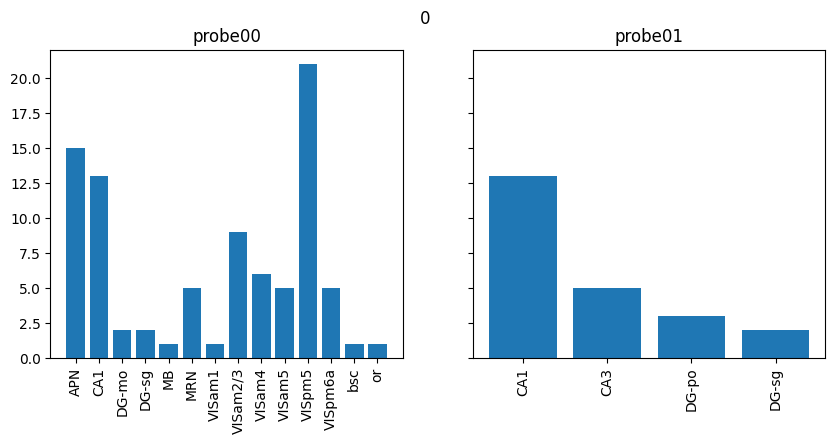

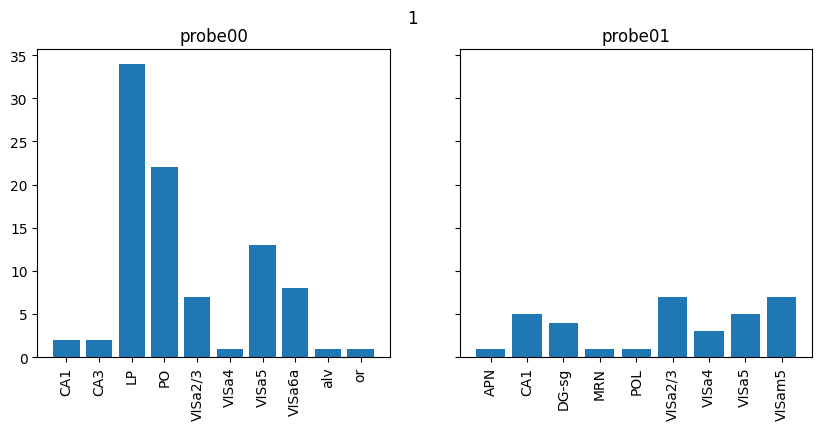

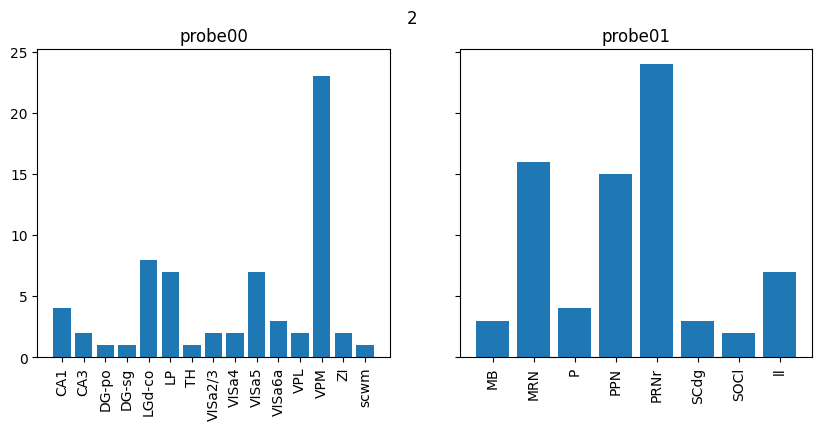

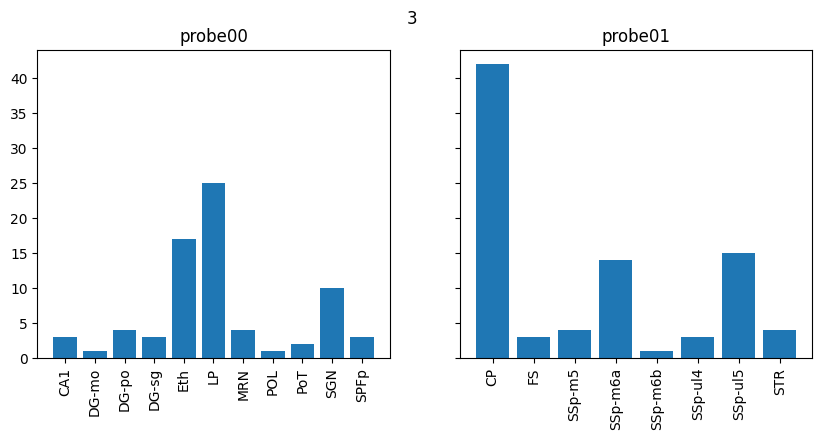

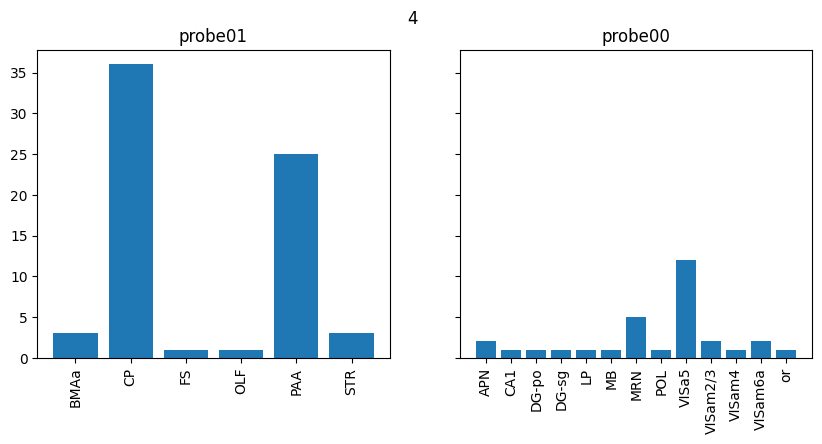

In [8]:
for idy, eid in tqdm(enumerate(eids_to_download)):
    pids, probes = one.eid2pid(eid)
    fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(10,4))
    for idx, pid in enumerate(pids):
        spikes, clusters = load_good_units(one, pid, compute_metrics=False)
        acry, numbers = np.unique(clusters.acronym, return_counts=True)
        ax[idx].bar(np.arange(len(acry)), numbers)
        ax[idx].set_xticks(np.arange(len(acry)), labels=acry, rotation=90)
        ax[idx].set_title(f'{probes[idx]}')
    plt.suptitle(f'{idy}')
    plt.show()

In [152]:
# we choose 1,2,3,4,5

eids_to_download[1:6].to_csv('../data/processed/eids_to_analyse.csv')

In [3]:
X = pd.read_csv('../data/processed/eids_to_analyse.csv')

In [4]:
X

,Unnamed: 0,eid
0,1,b52182e7-39f6-4914-9717-136db589706e
1,2,f312aaec-3b6f-44b3-86b4-3a0c119c0438
2,3,54238fd6-d2d0-4408-b1a9-d19d24fd29ce
3,4,7af49c00-63dd-4fed-b2e0-1b3bd945b20b
4,5,4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b


In [7]:
eids_to_download = X.eid